In [3]:
import numpy as np


In [4]:
# def calculate_upper_triangular_matrix(A,b):
#     N = int(np.sqrt(len(A)))
#     A = np.array(A, dtype=float).reshape(N,N)
#     b = np.array(b, dtype=float)
#     for i in range(0,N):
#         for j in range(i+1,N):
#             c = -(A[j,i]/A[i,i])
#             b[j] = b[j] + c*b[i]
#             for k in range(0,N):
#                 A[j,k] = A[j,k] + (c*A[i,k])
#     return A,b

def backsubstitution(A_bar,b_bar):
    N = int(A_bar.shape[0])
    x_vec = np.zeros_like(b_bar, dtype=float)
    for i in range(N-1,-1,-1):
        if i==N-1:
            x_vec[i] = b_bar[i]/A_bar[i,i]
        else:
            sigma_val = []
            for j in range(i+1,N):
                sigma_val.append(A_bar[i,j]*x_vec[j])
            sigma_val_sum = sum(sigma_val)
            x_vec[i] = (b_bar[i] - sigma_val_sum)/A_bar[i,i]
    return x_vec


In [6]:
A = [1,2,1,-2,1,-1,1,1,2]
b = [3,4,7]
A_bar, b_bar = calculate_upper_triangular_matrix(A,b)
print(backsubstitution(A_bar, b_bar))
print(b)

[-4.  1.  5.]
[3, 4, 7]


In [7]:
print(A_bar)
print(b_bar)

[[1.  2.  1. ]
 [0.  5.  1. ]
 [0.  0.  1.2]]
[ 3. 10.  6.]


In [34]:
def calculate_upper_triangular_matrix(A, b):
    N = int(np.sqrt(len(A)))
    A = np.array(A, dtype=float).reshape(N, N)
    b = np.array(b, dtype=float)

    for i in range(0, N):
        idx = i + np.argmax(np.abs(A[i:, i]))
        if A[idx, i] == 0:
            raise ValueError("Matrix is singular; no unique solution exists.")
        if idx != i:
            A[[i, idx], :] = A[[idx, i], :]
            b[[i, idx]] = b[[idx, i]]   # <-- swap b too!
        for j in range(i + 1, N):
            c = -(A[j, i] / A[i, i])
            b[j] = b[j] + c * b[i]
            for k in range(0, N):
                A[j, k] = A[j, k] + (c * A[i, k])

    return A, b

In [ ]:
# A = [0,2,1,3,1,4,2,1,3]
# b = [3,7,6]
import time
def gaussiansolve(A,b):
    time_i = time.time()
    A_bar, b_bar = calculate_upper_triangular_matrix(A,b)
    x = backsubstitution(A_bar, b_bar)
    time_f = time.time()
    print(f"Execution time: {time_f - time_i} seconds")
    return x

N = 50
A = np.random.rand(N, N).flatten().tolist()
b = np.random.rand(N).flatten().tolist()
gaussiansolve(A,b)


Execution time: 0.02439093589782715 seconds


array([-1.61092336,  2.6417931 , -4.34761202, -0.48974599, -1.75967951,
       -0.55555308,  1.51792589,  1.55814024,  0.97948488,  1.57526085,
        4.39544838, -0.5451841 ,  0.39483809,  0.35913384, -1.24099223,
        2.138206  , -0.96234531, -0.60544188, -1.1359384 ,  0.54246068,
        2.10707452, -0.90510866, -0.3530794 ,  1.02389539,  0.53970617,
       -0.51206462, -1.57621519, -0.97069881, -0.35645392,  3.3038443 ,
        0.89176499,  0.59680175,  0.15735301, -0.48629183,  0.83509104,
        1.11442432, -2.75793353, -2.17879602, -0.76980004,  3.52053577,
        1.27194905, -0.15445727, -1.44632884, -4.13090011,  0.36343883,
        0.26903254,  2.42886721, -1.08935571, -1.2222091 , -1.97087064])

N=20: 0.002936 seconds
N=50: 0.022229 seconds
N=100: 0.128826 seconds
N=500: 14.979813 seconds

Log-log fit: log(runtime) = 2.6752 * log(N) + -14.1009
Slope (complexity exponent): 2.6752


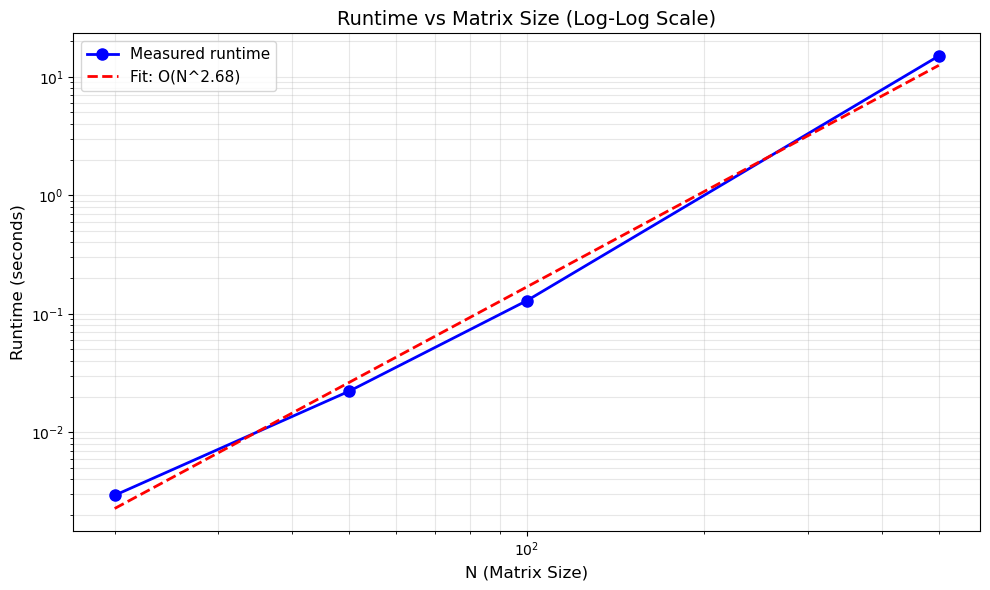

In [43]:
import matplotlib.pyplot as plt

# Test different values of N and measure runtime
N_values = [20,50,100,500]
runtimes = []

for N in N_values:
    A = np.random.rand(N, N).flatten().tolist()
    b = np.random.rand(N).flatten().tolist()
    
    time_i = time.time()
    A_bar, b_bar = calculate_upper_triangular_matrix(A, b)
    x = backsubstitution(A_bar, b_bar)
    time_f = time.time()
    
    runtime = time_f - time_i
    runtimes.append(runtime)
    print(f"N={N}: {runtime:.6f} seconds")

# Calculate slope in log-log space
# log(runtime) = slope * log(N) + intercept
coefficients = np.polyfit(np.log(N_values), np.log(runtimes), 1)
slope = coefficients[0]
intercept = coefficients[1]
print(f"\nLog-log fit: log(runtime) = {slope:.4f} * log(N) + {intercept:.4f}")
print(f"Slope (complexity exponent): {slope:.4f}")

# Plot on log-log scale
plt.figure(figsize=(10, 6))
plt.loglog(N_values, runtimes, 'bo-', linewidth=2, markersize=8, label='Measured runtime')

# Plot the fitted line
fitted_runtimes = np.exp(intercept) * np.array(N_values)**slope
plt.loglog(N_values, fitted_runtimes, 'r--', linewidth=2, label=f'Fit: O(N^{slope:.2f})')

plt.xlabel('N (Matrix Size)', fontsize=12)
plt.ylabel('Runtime (seconds)', fontsize=12)
plt.title('Runtime vs Matrix Size (Log-Log Scale)', fontsize=14)
plt.grid(True, alpha=0.3, which='both')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()